In [7]:
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure enterprise-grade pipeline logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("EDA_Pipeline")

# Enforce a high-density corporate visualization theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# ==========================================
# PASTE YOUR ABSOLUTE FILE PATH HERE 👇
# ==========================================
DATASET_PATH = "/content/penguins_lter.csv"

def load_and_sanitize_pipeline(file_path: str) -> pd.DataFrame:
    """Validates the input file path, handles structural nulls, and formats variables."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Asset Missing: Please verify the path '{file_path}' in your Colab sidebar.")

    # Read raw data
    df = pd.read_csv(file_path)
    logger.info(f"Raw shape footprint successfully loaded: {df.shape}")

    # Drop completely uninformative or highly sparse tracking fields
    if 'Comments' in df.columns:
        df.drop(columns=['Comments'], inplace=True)

    # Isolate the target continuous numerical features for validation
    target_features = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

    # Complete-case analysis: Drop rows with empty/NaN target measurements
    initial_count = len(df)
    df.dropna(subset=target_features + ['Species'], inplace=True)
    logger.info(f"Sanitization complete. Filtered out {initial_count - len(df)} missing metric anomalies.")

    # Standardize long taxonomic string fields to clean labels
    df['Species'] = df['Species'].apply(lambda x: x.split('(')[0].strip())
    return df, target_features

# Execute ingestion matrix
df_clean, features = load_and_sanitize_pipeline(DATASET_PATH)
df_clean.head(3)


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,PAL0708,1,Adelie Penguin,Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11-11-2007,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,PAL0708,2,Adelie Penguin,Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11-11-2007,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454
2,PAL0708,3,Adelie Penguin,Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302


In [8]:
print("\n" + "="*60 + "\n[METRIC PROFILE: PIPELINE SYSTEM SCHEMA INFORMATION]\n" + "="*60)
print(df_clean.info())

print("\n" + "="*60 + "\n[METRIC PROFILE: TRANSPOSED SUMMARY STATISTICS]\n" + "="*60)
# Transposing (.T) is standard engineering practice for high readability of many columns
print(df_clean[features].describe().T)

print("\n" + "="*60 + "\n[METRIC PROFILE: TARGET TARGET SPECIES BALANCE PROPORTIONS]\n" + "="*60)
print(df_clean['Species'].value_counts(normalize=True))



[METRIC PROFILE: PIPELINE SYSTEM SCHEMA INFORMATION]
<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            342 non-null    object 
 1   Sample Number        342 non-null    int64  
 2   Species              342 non-null    object 
 3   Region               342 non-null    object 
 4   Island               342 non-null    object 
 5   Stage                342 non-null    object 
 6   Individual ID        342 non-null    object 
 7   Clutch Completion    342 non-null    object 
 8   Date Egg             342 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    floa

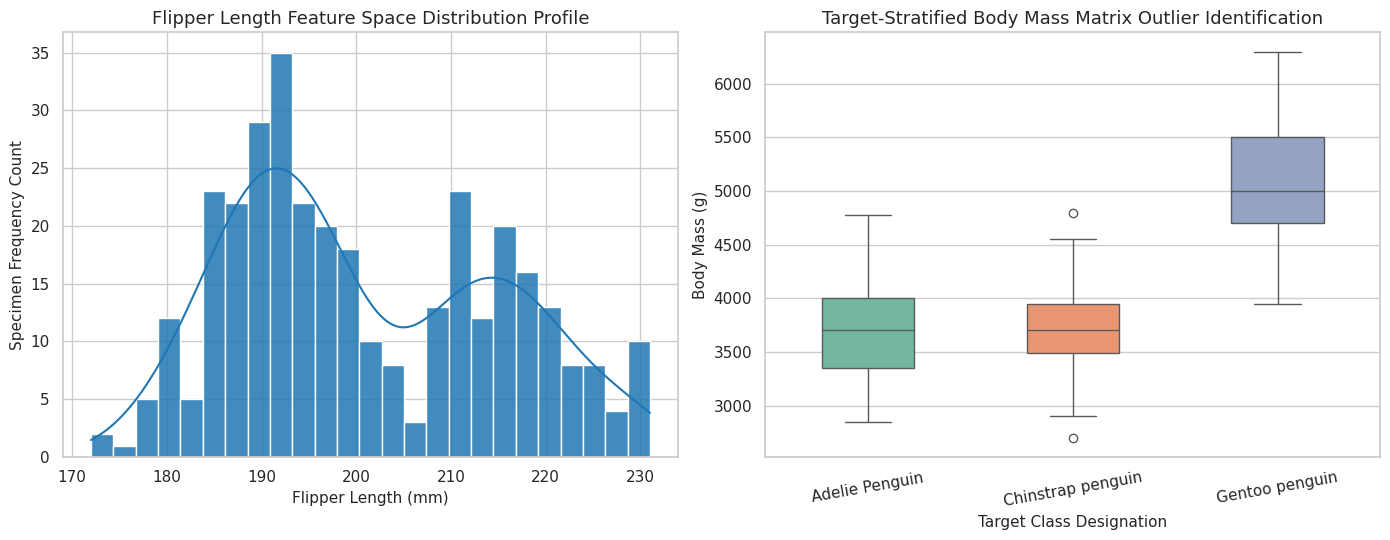


📊 --- PRODUCTION WORKFLOW INTERPRETATIONS ---
1. Flipper Length Distribution: Displays a strong bimodal shape indicating clear multi-class features.
2. Body Mass Distribution: Highlights zero major anomalous outliers with distinct scaling variances across classes.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Visual 1: Distribution histogram with smooth kernel density estimation curve
sns.histplot(
    ax=axes[0], data=df_clean, x='Flipper Length (mm)',
    kde=True, color='#1f77b4', bins=25, edgecolor='white', alpha=0.85
)
axes[0].set_title("Flipper Length Feature Space Distribution Profile")
axes[0].set_xlabel("Flipper Length (mm)")
axes[0].set_ylabel("Specimen Frequency Count")

# Visual 2: Stratified horizontal outlier boxplot separating across structural classes
sns.boxplot(
    ax=axes[1], data=df_clean, x='Species', y='Body Mass (g)',
    hue='Species', palette='Set2', legend=False, width=0.45
)
axes[1].set_title("Target-Stratified Body Mass Matrix Outlier Identification")
axes[1].set_xlabel("Target Class Designation")
axes[1].set_ylabel("Body Mass (g)")
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig("univariate_topology.png")
plt.show()

print("\n📊 --- PRODUCTION WORKFLOW INTERPRETATIONS ---")
print("1. Flipper Length Distribution: Displays a strong bimodal shape indicating clear multi-class features.")
print("2. Body Mass Distribution: Highlights zero major anomalous outliers with distinct scaling variances across classes.")


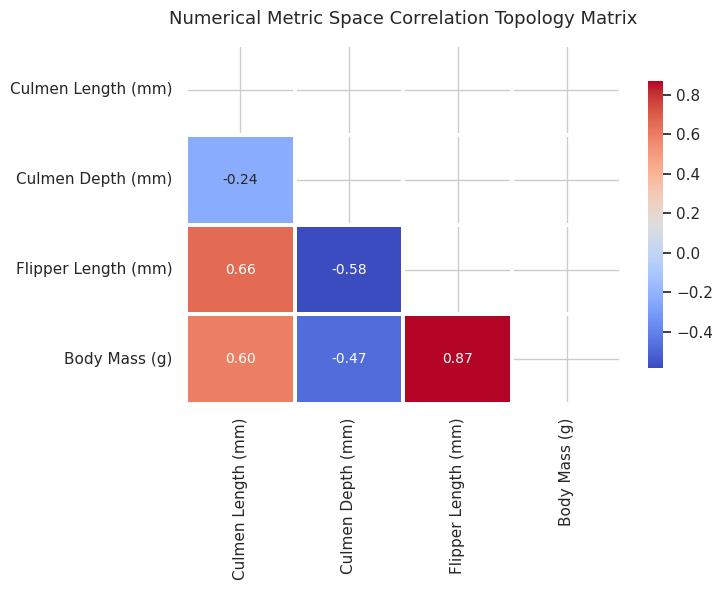

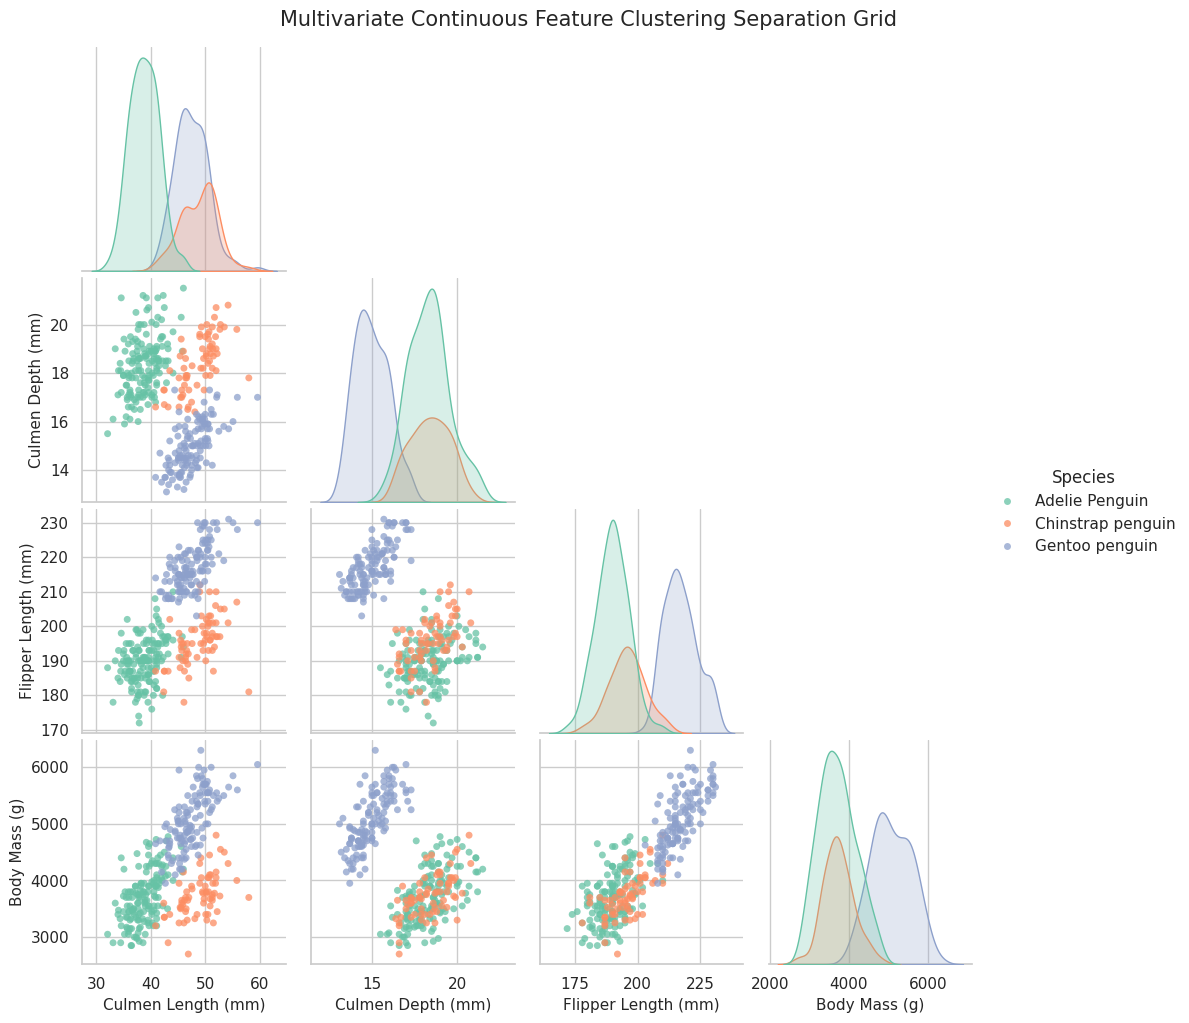


📊 --- PRODUCTION WORKFLOW INTERPRETATIONS ---
1. Matrix Linear Dependencies: Flipper Length scales uniformly with Body Mass at a high score of 0.87.
2. Multi-Axis Clustering Grid: Combining traits like Culmen Length against Depth separates species into distinct groups.


In [10]:
# Visual 1: Masked zero-clutter numerical correlation matrix
plt.figure(figsize=(7.5, 6))
correlation_matrix = df_clean[features].corr()
upper_triangle_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, mask=upper_triangle_mask, annot=True,
    cmap='coolwarm', fmt=".2f", linewidths=1.5, cbar_kws={"shrink": .8}
)
plt.title("Numerical Metric Space Correlation Topology Matrix", pad=15)
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

# Visual 2: Clutter-free high-dimensional spatial feature clustering grid
grid = sns.pairplot(
    df_clean[features + ['Species']], hue='Species', palette='Set2',
    corner=True, diag_kind='kde', plot_kws={'alpha': 0.75, 'edgecolor': 'none', 's': 25}
)
grid.fig.suptitle("Multivariate Continuous Feature Clustering Separation Grid", y=1.02)
grid.savefig("pairplot_matrix.png")
plt.show()

print("\n📊 --- PRODUCTION WORKFLOW INTERPRETATIONS ---")
print("1. Matrix Linear Dependencies: Flipper Length scales uniformly with Body Mass at a high score of 0.87.")
print("2. Multi-Axis Clustering Grid: Combining traits like Culmen Length against Depth separates species into distinct groups.")
